# 01 · Exploración de datos (EDA) — Detección de fraude

Abrimos la muestra que dejó `fraud/dataset.py` en `data/raw/` y la miramos:
estructura, balance de clases y qué features separan fraude de no-fraude.

> **Requisito:** correr antes `./.venv/bin/python -m fraud.dataset` para generar
> `data/raw/fraud_sample.parquet`.

> **Distribución real:** la muestra conserva la proporción real de fraude (~1%),
> así que vas a ver un fuerte desbalance en el balance de clases. Las tasas por
> grupo son honestas, pero con pocos fraudes pueden ser algo ruidosas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from fraud.config import RAW_DATA_DIR

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 12,
})

COLOR_LEGIT = "#0072B2"
COLOR_FRAUD = "#D55E00"
COLOR_ONE   = "#0072B2"

2026-09-04 19:06:30.148 | INFO     | fraud.config:<module>:11 - PROJ_ROOT path is: /Users/prisci/Documents/MIA/repo/fraud-detection


In [2]:
df = pd.read_parquet(RAW_DATA_DIR / "fraud_sample.parquet")
print("Filas, columnas:", df.shape)
df.dtypes

Filas, columnas: (1296675, 11)


trans_date_trans_time        str
category                     str
amt                      float64
gender                       str
city_pop                   int64
lat                      float64
long                     float64
merch_lat                float64
merch_long               float64
dob                          str
is_fraud                   int64
dtype: object

In [3]:
df.head()

,trans_date_trans_time,category,amt,gender,city_pop,lat,long,merch_lat,merch_long,dob,is_fraud
0,2019-01-01 00:00:18,misc_net,4.97,F,3495,36.0788,-81.1781,36.011293,-82.048315,1988-03-09,0
1,2019-01-01 00:00:44,grocery_pos,107.23,F,149,48.8878,-118.2105,49.159047,-118.186462,1978-06-21,0
2,2019-01-01 00:00:51,entertainment,220.11,M,4154,42.1808,-112.2620,43.150704,-112.154481,1962-01-19,0
3,2019-01-01 00:01:16,gas_transport,45.00,M,1939,46.2306,-112.1138,47.034331,-112.561071,1967-01-12,0
4,2019-01-01 00:03:06,misc_pos,41.96,M,99,38.4207,-79.4629,38.674999,-78.632459,1986-03-28,0


## 1. Balance de clases

¿Cuántas transacciones son fraude vs legítimas en la muestra?

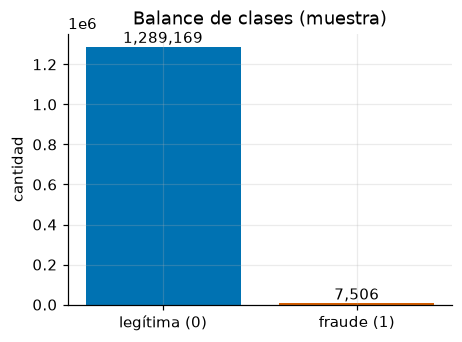

In [4]:
counts = df["is_fraud"].value_counts().sort_index()
labels = ["legítima (0)", "fraude (1)"]

fig, ax = plt.subplots(figsize=(4.5, 3.2))
bars = ax.bar(labels, counts.values, color=[COLOR_LEGIT, COLOR_FRAUD])
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:,}", ha="center", va="bottom")
ax.set_ylabel("cantidad")
ax.set_title("Balance de clases (muestra)")
plt.show()

## 2. Monto (`amt`) por clase

El monto suele ser la feature más predictiva del fraude. Comparamos la
distribución (sin outliers extremos para que se lea bien).

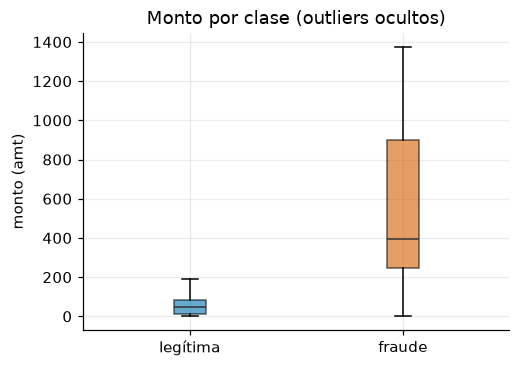

                mean      50%       max
is_fraud                               
0          67.667110   47.280  28948.90
1         531.320092  396.505   1376.04


In [5]:
data = [df.loc[df.is_fraud == 0, "amt"], df.loc[df.is_fraud == 1, "amt"]]

fig, ax = plt.subplots(figsize=(5, 3.5))
bp = ax.boxplot(data, tick_labels=["legítima", "fraude"], showfliers=False, patch_artist=True)
for patch, c in zip(bp["boxes"], [COLOR_LEGIT, COLOR_FRAUD]):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)
for median in bp["medians"]:
    median.set_color("#333333")
ax.set_ylabel("monto (amt)")
ax.set_title("Monto por clase (outliers ocultos)")
plt.show()

print(df.groupby("is_fraud")["amt"].describe()[["mean", "50%", "max"]])

## 3. Derivar `hour` y `age` (solo para explorar)

`trans_date_trans_time` y `dob` son texto. Sacamos la hora del día y la edad.
(En el pipeline real esto vive en `fraud/features.py`; acá lo hacemos inline
para poder graficar.)

In [6]:
df["hour"] = df["trans_date_trans_time"].str.slice(11, 13).astype(int)
df["age"] = (
    df["trans_date_trans_time"].str.slice(0, 4).astype(int)
    - df["dob"].str.slice(0, 4).astype(int)
)
df[["trans_date_trans_time", "hour", "dob", "age"]].head()

,trans_date_trans_time,hour,dob,age
0,2019-01-01 00:00:18,0,1988-03-09,31
1,2019-01-01 00:00:44,0,1978-06-21,41
2,2019-01-01 00:00:51,0,1962-01-19,57
3,2019-01-01 00:01:16,0,1967-01-12,52
4,2019-01-01 00:03:06,0,1986-03-28,33


## 4. Tasa de fraude por hora del día

¿El fraude tiene patrón horario? (Suele concentrarse de madrugada.)

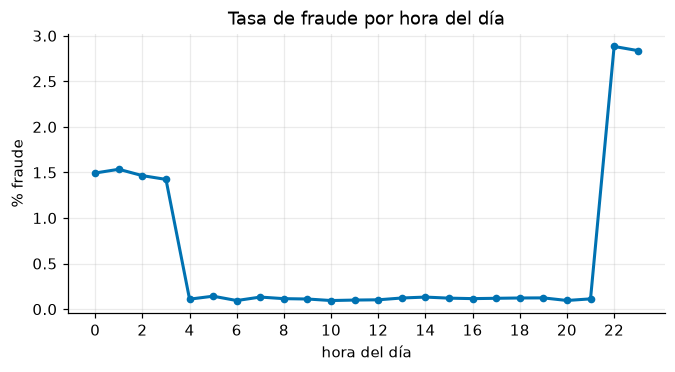

In [7]:
rate_hour = df.groupby("hour")["is_fraud"].mean() * 100

fig, ax = plt.subplots(figsize=(7, 3.3))
ax.plot(rate_hour.index, rate_hour.values, color=COLOR_ONE, linewidth=2, marker="o", markersize=4)
ax.set_xlabel("hora del día")
ax.set_ylabel("% fraude")
ax.set_title("Tasa de fraude por hora del día")
ax.set_xticks(range(0, 24, 2))
plt.show()

## 5. Tasa de fraude por rubro (`category`)

¿Hay rubros más golpeados por el fraude? (Ordenado para leerlo de un vistazo.)

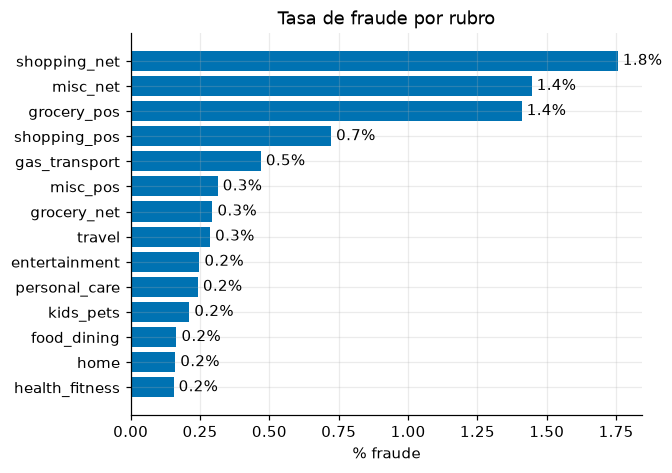

In [8]:
rate_cat = (df.groupby("category")["is_fraud"].mean() * 100).sort_values()

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.barh(rate_cat.index, rate_cat.values, color=COLOR_ONE)
for i, v in enumerate(rate_cat.values):
    ax.text(v, i, f" {v:.1f}%", va="center")
ax.set_xlabel("% fraude")
ax.set_title("Tasa de fraude por rubro")
plt.show()

## 6. Tasa de fraude por género

Un chequeo rápido de otra categórica.

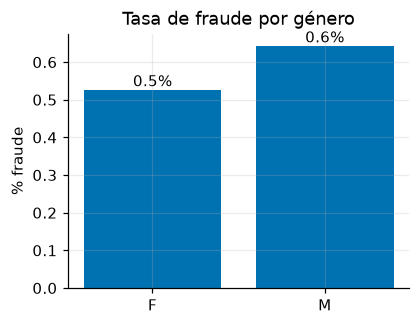

In [9]:
rate_gender = df.groupby("gender")["is_fraud"].mean() * 100

fig, ax = plt.subplots(figsize=(4, 3))
bars = ax.bar(rate_gender.index, rate_gender.values, color=COLOR_ONE)
for b, v in zip(bars, rate_gender.values):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.1f}%", ha="center", va="bottom")
ax.set_ylabel("% fraude")
ax.set_title("Tasa de fraude por género")
plt.show()

## Conclusiones 
- **`amt`** es fuertemente predictiva: el fraude tiene montos mucho más altos.
- **`hour`** aporta señal: el fraude no se reparte parejo en el día.
- **`category`**: `*_net` y compras online con más fraude que otros.
- `category` y `gender` son categóricas